# BÀI TẬP: TITANIC
**Nguồn:** kaggle.com/c/titanic (891 dòng)


## Setup

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

csv_path = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'

df = pd.read_csv(csv_path)
print('Loaded from:', csv_path)
df.head()

Loaded from: https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
# PHẦN A — DATA PROFILING
## A.1. Data size, column names, data types

In [2]:
print("Số dòng:", df.shape[0], "| Số cột:", df.shape[1])
print()
df.info()

Số dòng: 891 | Số cột: 15

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


## A.2. Missing values & Duplicate data

In [3]:
missing = df.isnull().sum()
print("Missing values:")
print(missing[missing>0] if missing.sum()>0 else "Không có cột nào thiếu dữ liệu.")
print()
print("Duplicate rows (toàn bộ):", df.duplicated().sum())

Missing values:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Duplicate rows (toàn bộ): 107


## A.3. Invalid values

In [4]:
print("age <= 0:", (df['age']<=0).sum())
print("fare < 0:", (df['fare']<0).sum())
print()
print("=> Dữ liệu khá sạch: không missing, không duplicate, không giá trị vô lý.")

age <= 0: 0
fare < 0: 0

=> Dữ liệu khá sạch: không missing, không duplicate, không giá trị vô lý.


## A.4. Create a new column
Tạo cột `family_size` = sibsp + parch + 1.

In [5]:
df['family_size'] = df['sibsp'] + df['parch'] + 1
df[['sibsp','parch','family_size']].head()

,sibsp,parch,family_size
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


---
# PHẦN B — DESCRIPTIVE STATISTICS

## Group 1 — Central Tendency (mean, median, mode)

In [6]:
for col in ['age','fare']:
    mean_, median_, mode_ = df[col].mean(), df[col].median(), df[col].mode()[0]
    print(f"{col}: Mean={mean_:.2f}, Median={median_:.2f}, Mode={mode_:.2f}")
print()
print("Mode sex:", df['sex'].mode()[0])

age: Mean=29.70, Median=28.00, Mode=24.00
fare: Mean=32.20, Median=14.45, Mode=8.05

Mode sex: male


## Group 2 — Dispersion (range, var, std, IQR, CV)

In [7]:
for col in ['age','fare']:
    s = df[col]
    range_ = s.max()-s.min()
    std_ = s.std()
    q1,q3 = s.quantile([0.25,0.75]); iqr = q3-q1
    cv = std_/s.mean()
    print(f"--- {col} ---")
    print(f"Range={range_:.2f}, Std={std_:.2f}, IQR={iqr:.2f}, CV={cv:.2f}")

--- age ---
Range=79.58, Std=14.53, IQR=17.88, CV=0.49
--- fare ---
Range=512.33, Std=49.69, IQR=23.09, CV=1.54


## Group 3 — Location and Shape (Percentile, Skewness, Kurtosis)

--- age ---
P25=20.12, P50=28.00, P75=38.00
Skewness=0.39, Kurtosis=0.17
--- fare ---
P25=7.91, P50=14.45, P75=31.00
Skewness=4.78, Kurtosis=33.20


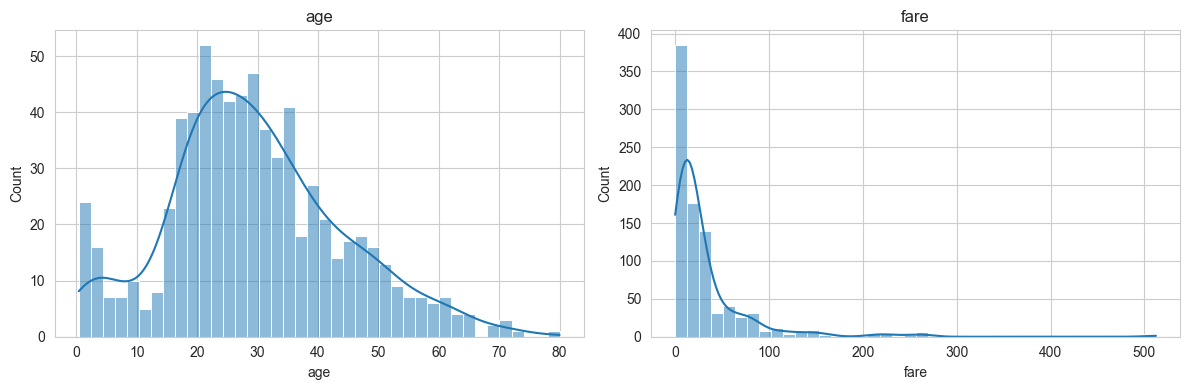

Nhận xét: fare lệch phải và có kurtosis cao hơn hẳn age -> nhiều outlier giá vé cực đoan hơn.


In [8]:
for col in ['age','fare']:
    s = df[col].dropna()
    skew_, kurt_ = stats.skew(s), stats.kurtosis(s)
    print(f"--- {col} ---")
    print(f"P25={s.quantile(0.25):.2f}, P50={s.quantile(0.5):.2f}, P75={s.quantile(0.75):.2f}")
    print(f"Skewness={skew_:.2f}, Kurtosis={kurt_:.2f}")

fig,axes = plt.subplots(1,2,figsize=(12,4))
sns.histplot(df['age'],bins=40,kde=True,ax=axes[0]); axes[0].set_title('age')
sns.histplot(df['fare'],bins=40,kde=True,ax=axes[1]); axes[1].set_title('fare')
plt.tight_layout(); plt.show()

print("Nhận xét: fare lệch phải và có kurtosis cao hơn hẳn age -> nhiều outlier giá vé cực đoan hơn.")

---
# PHẦN C — DEFINE THE QUESTION

Mỗi câu hỏi dưới đây theo đúng cấu trúc: **Câu hỏi → Code → Kết quả → Insight**.

## Câu hỏi 1: Hạng vé nào có tỷ lệ sống sót cao nhất, chênh lệch bao nhiêu so với hạng thấp nhất?

pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64

=> Hạng vé 1 có tỷ lệ sống sót cao nhất (63.0%).
=> Chênh lệch so với hạng thấp nhất (Hạng 3): 38.7%.


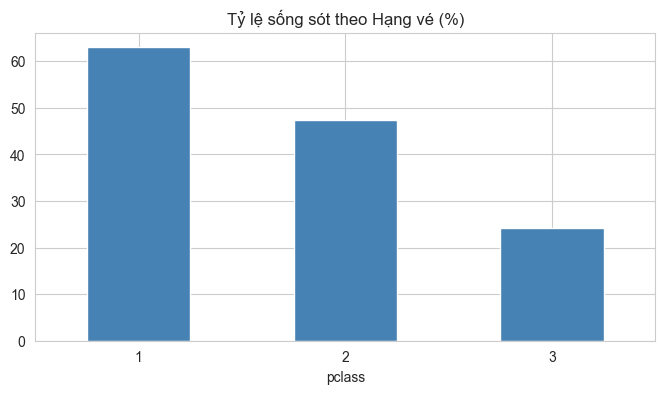

In [9]:
surv_by_pclass = df.groupby('pclass')['survived'].mean() * 100
surv_by_pclass = surv_by_pclass.sort_values(ascending=False)
top_class = surv_by_pclass.index[0]
low_class = surv_by_pclass.index[-1]
diff = surv_by_pclass.iloc[0] - surv_by_pclass.iloc[-1]

print(surv_by_pclass.round(2))
print(f"\n=> Hạng vé {top_class} có tỷ lệ sống sót cao nhất ({surv_by_pclass.iloc[0]:.1f}%).")
print(f"=> Chênh lệch so với hạng thấp nhất (Hạng {low_class}): {diff:.1f}%.")

fig,ax=plt.subplots(figsize=(8,4))
surv_by_pclass.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Tỷ lệ sống sót theo Hạng vé (%)'); plt.xticks(rotation=0); plt.show()

**Insight:** Tỷ lệ sống sót tập trung cao nhất vào Hạng 1 và giảm dần theo Hạng vé — Hạng 1 có lợi thế lớn về vị trí khoang cabin tiếp cận xuồng cứu sinh.

## Câu hỏi 2: Giới tính hay hạng vé ảnh hưởng đến sống sót mạnh hơn?

In [10]:
surv_sex = df.groupby('sex')['survived'].mean() * 100
surv_pclass = df.groupby('pclass')['survived'].mean() * 100

diff_sex = surv_sex['female'] - surv_sex['male']
diff_pclass = surv_pclass.max() - surv_pclass.min()

print("Tỷ lệ sống theo Giới tính (%):\n", surv_sex.round(2))
print("Tỷ lệ sống theo Hạng vé (%):\n", surv_pclass.round(2))
print(f"\n=> Chênh lệch theo Giới tính: {diff_sex:.1f}%")
print(f"=> Chênh lệch theo Hạng vé: {diff_pclass:.1f}%")

Tỷ lệ sống theo Giới tính (%):
 sex
female    74.20
male      18.89
Name: survived, dtype: float64
Tỷ lệ sống theo Hạng vé (%):
 pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64

=> Chênh lệch theo Giới tính: 55.3%
=> Chênh lệch theo Hạng vé: 38.7%


**Insight:** Giới tính ảnh hưởng mạnh hơn Hạng vé (chênh lệch giữa Nữ và Nam là 55.3%, cao hơn mức 38.7% của Hạng vé) do chính sách ưu tiên "phụ nữ và trẻ em".

## Câu hỏi 3: Vé đắt hơn có thực sự sống sót cao hơn không?

Pearson correlation: 0.257
Spearman correlation: 0.324


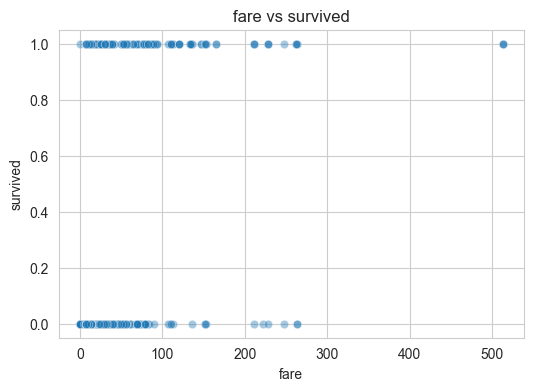

In [11]:
corr_pearson = df['fare'].corr(df['survived'])
corr_spearman = df['fare'].corr(df['survived'], method='spearman')
print(f"Pearson correlation: {corr_pearson:.3f}")
print(f"Spearman correlation: {corr_spearman:.3f}")

fig,ax=plt.subplots(figsize=(6,4))
sns.scatterplot(data=df, x='fare', y='survived', alpha=0.4, ax=ax)
ax.set_title('fare vs survived'); plt.show()

**Insight:** Hệ số tương quan cho biết mức độ liên hệ giữa 2 biến, nhưng **tương quan không chứng minh nhân quả** — giá vé cao có tương quan dương với khả năng sống sót nhưng nguyên nhân chính do hành khách mua vé Hạng 1.

## Câu hỏi 4: Gia đình đông người có ảnh hưởng đến khả năng sống sót không?

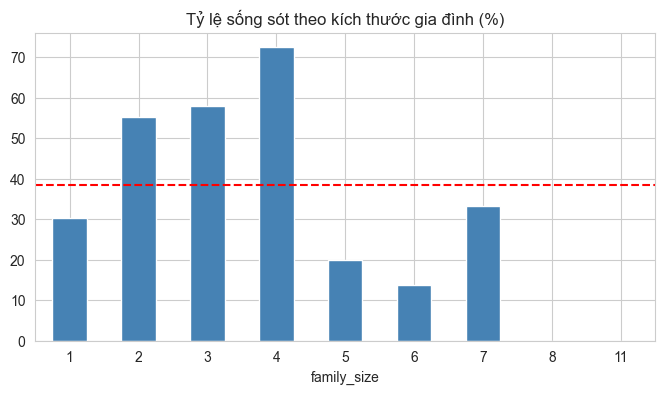

Kích thước gia đình sống cao nhất: 4 (72.4%)
Kích thước gia đình sống thấp nhất: 8 (0.0%)


In [12]:
fam_surv = df.groupby('family_size')['survived'].mean() * 100

fig,ax=plt.subplots(figsize=(8,4))
fam_surv.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(df['survived'].mean()*100, color='red', linestyle='--')
ax.set_title('Tỷ lệ sống sót theo kích thước gia đình (%)')
plt.xticks(rotation=0); plt.show()

peak = fam_surv.idxmax()
low = fam_surv.idxmin()
print(f"Kích thước gia đình sống cao nhất: {peak} ({fam_surv[peak]:.1f}%)")
print(f"Kích thước gia đình sống thấp nhất: {low} ({fam_surv[low]:.1f}%)")

**Insight:** Tỷ lệ sống sót phụ thuộc rõ rệt vào kích thước gia đình — nhóm gia đình nhỏ (2-4 người) có tỷ lệ sống cao nhất, trong khi đi đơn độc hoặc gia đình quá đông có tỷ lệ sống sót thấp hơn.

## Câu hỏi 5: Cảng lên tàu (embark_town) nào có tỷ lệ sống sót cao nhất?

In [13]:
embark_surv = df.groupby('embark_town')['survived'].mean() * 100
print(embark_surv.sort_values(ascending=False).round(2))

top_town = embark_surv.idxmax()
print(f"\n=> Cảng lên tàu có tỷ lệ sống sót cao nhất: {top_town} ({embark_surv[top_town]:.1f}%)")

embark_town
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: survived, dtype: float64

=> Cảng lên tàu có tỷ lệ sống sót cao nhất: Cherbourg (55.4%)


**Insight:** Cảng Cherbourg có tỷ lệ sống sót cao nhất (55.4%) — đây là tín hiệu cho thấy cơ cấu hành khách ở các cảng khác nhau (Cherbourg tập trung nhiều vé Hạng 1 hơn).

## Câu hỏi 6 (Tổng hợp) — Viết insight tổng hợp
Dựa trên Phần A, B, C, viết 4-5 câu insight tổng thể về dữ liệu Titanic.

**Insight:** Giới tính (Nữ) và Hạng vé (Hạng 1) là hai yếu tố quyết định hàng đầu đến tỷ lệ sống sót trên tàu Titanic. Hành khách đi cùng gia đình nhỏ (2-4 người) có khả năng sống cao nhất, trong khi giá vé (Fare) và Cảng lên tàu (Cherbourg) phản ánh gián tiếp vị trí khoang cabin và phân lớp thượng lưu.

---
# TỔNG KẾT

| Phần | Trả lời câu hỏi |
|---|---|
| A — Data Profiling | Dữ liệu có sạch, đáng tin cậy để phân tích không? |
| B — Descriptive Statistics | Từng biến (age, fare) có đặc điểm gì (trung tâm, phân tán, hình dạng)? |
| C — Define the Question | Trả lời được bao nhiêu câu hỏi kinh doanh thật, có insight + khuyến nghị hành động? |

— khác với việc chỉ chạy `describe()` hay `value_counts()` đơn thuần, mỗi phân tích ở Phần C đều xuất phát từ 1 câu hỏi cụ thể và kết thúc bằng 1 insight có thể hành động được, đúng tinh thần "data storytelling" mà nhà tuyển dụng Data Analyst luôn tìm kiếm.